# Novella Bind Score — Phase 1: the data story

What this notebook does: **understand the data, find the signal, decide which features to build.**
(Modeling, training, and the ranking comparison live in **`02_model.ipynb`**.)

**Data model**
- `submissions`: one row per submission — `createdDate`, `resolvedDate`, `agentEmail` (the *customer* / retail agent), `label` (1=sold).
- `events`: time-ordered stream per submission — type ∈ {EMAIL_INBOUND (customer→Novella), EMAIL_OUTBOUND (Novella→customer), QUOTE_RECEIVED (carrier offer)}, plus `email_char_count`, `email_attachment_count` (null for quotes).
- `t` = days since `createdDate`. A feature at (sub, t) may use **only** events with `event_date ≤ createdDate + t`; never `resolvedDate`/`label`.

⚠️ The exploration below aggregates the **full lifecycle** (directional only). Model features are recomputed **per t**, leakage-safe, in `02_model.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
DATA = next(p / "data" for p in [ROOT, ROOT.parent] if (p / "data").exists())

subs = pd.read_csv(DATA / "features_submissions.csv", parse_dates=["createdDate", "resolvedDate"])
events = pd.read_csv(DATA / "features_events.csv", parse_dates=["event_date"])

subs["resolution_days"] = (subs.resolvedDate - subs.createdDate).dt.total_seconds() / 86400
events = events.merge(subs[["submissionId", "createdDate"]], on="submissionId", how="left")
events["days_since_create"] = (events.event_date - events.createdDate).dt.total_seconds() / 86400

print("submissions:", subs.shape, "| events:", events.shape)
subs.head()

submissions: (881, 6) | events: (17211, 7)


,submissionId,createdDate,resolvedDate,agentEmail,label,resolution_days
0,1,2020-01-01 00:00:00,2020-02-11 08:19:16,1@gmail.com,0,41.346713
1,2,2020-01-01 04:08:26,2020-01-15 03:01:10,2@gmail.com,0,13.953287
2,3,2020-01-01 05:54:25,2020-01-09 01:41:13,3@gmail.com,0,7.824167
3,4,2020-01-01 06:56:10,2020-01-22 03:26:08,4@gmail.com,0,20.854144
4,5,2020-01-01 07:04:16,2020-01-10 01:35:32,5@gmail.com,0,8.771713


## Per-submission inspector

In [2]:
def show(sid):
    row = subs[subs.submissionId == sid].iloc[0]
    print("=" * 70)
    print(f"SUBMISSION {sid}")
    print(f"  created : {row.createdDate}")
    print(f"  resolved: {row.resolvedDate}  ({row.resolution_days:.2f}d)")
    print(f"  agent   : {row.agentEmail}")
    print(f"  label   : {row.label}  ({'SOLD' if row.label == 1 else 'not sold'})")
    ev = events[events.submissionId == sid].sort_values("event_date")
    print(f"  events ({len(ev)}):")
    for _, r in ev.iterrows():
        print(f"    {r.event_date}  d={r.days_since_create:+6.2f}  {r.event_type:15s}"
              f"  chars={r.email_char_count!s:>6}  attach={r.email_attachment_count!s:>4}")

show(1)    # not sold, heavy back-and-forth, got a quote
show(11)   # SOLD in 13 minutes, 2 emails

SUBMISSION 1
  created : 2020-01-01 00:00:00
  resolved: 2020-02-11 08:19:16  (41.35d)
  agent   : 1@gmail.com
  label   : 0  (not sold)
  events (24):
    2019-12-31 23:59:54  d= -0.00  EMAIL_INBOUND    chars= 605.0  attach=12.0
    2020-01-01 01:12:54  d= +0.05  EMAIL_OUTBOUND   chars= 574.0  attach= 1.0
    2020-01-02 01:12:57  d= +1.05  EMAIL_OUTBOUND   chars= 305.0  attach= 0.0
    2020-01-03 01:13:00  d= +2.05  EMAIL_OUTBOUND   chars= 307.0  attach= 0.0
    2020-01-03 01:19:44  d= +2.06  EMAIL_INBOUND    chars= 269.0  attach= 1.0
    2020-01-03 01:42:41  d= +2.07  EMAIL_OUTBOUND   chars= 204.0  attach= 0.0
    2020-01-04 02:00:56  d= +3.08  QUOTE_RECEIVED   chars=   nan  attach= nan
    2020-01-04 03:19:27  d= +3.14  EMAIL_OUTBOUND   chars=1000.0  attach= 1.0
    2020-01-04 03:49:36  d= +3.16  EMAIL_INBOUND    chars= 435.0  attach= 1.0
    2020-01-06 00:43:45  d= +5.03  EMAIL_OUTBOUND   chars= 205.0  attach= 0.0
    2020-01-06 01:59:39  d= +5.08  EMAIL_INBOUND    chars= 342.0  at

## Profiling

In [3]:
print("label distribution:"); print(subs.label.value_counts())
print(f"bind rate: {subs.label.mean():.1%}\n")
print("resolution_days by label:")
print(subs.groupby("label").resolution_days.describe()[["count", "mean", "50%", "max"]], "\n")
print("event_type counts:"); print(events.event_type.value_counts())

label distribution:
label
0    751
1    130
Name: count, dtype: int64
bind rate: 14.8%

resolution_days by label:
       count       mean        50%         max
label                                         
0      751.0  27.976530  21.000069  194.014271
1      130.0  33.447994  23.746997  152.995289 

event_type counts:
event_type
EMAIL_OUTBOUND    9712
EMAIL_INBOUND     6355
QUOTE_RECEIVED    1144
Name: count, dtype: int64


In [ ]:
# --- Data quality: full validation battery + the cleaning we apply (details in reports/04_data_quality.md) ---
import sys
sys.path.insert(0, str(next(p for p in [ROOT, ROOT.parent] if (p / "src").exists())))
from src.preprocessing import validate, clean

raw_events = pd.read_csv(DATA / "features_events.csv", parse_dates=["event_date"])
print(validate(raw_events, subs).to_string(index=False))
_, log = clean(raw_events, subs)
print("\ncleaning applied:", log)

## What's visible at each t (the leakage window)

In [4]:
def visible_events(sid, t):
    """Events for sid with days_since_create <= t (the leakage-safe prefix)."""
    ev = events[events.submissionId == sid]
    return ev[ev.days_since_create <= t]

for t in [0, 7, 30]:
    ev = visible_events(1, t)
    print(f"sub 1 @ t={t:2d}: {len(ev):2d} events, has_quote={(ev.event_type=='QUOTE_RECEIVED').any()}")

sub 1 @ t= 0:  1 events, has_quote=False
sub 1 @ t= 7: 12 events, has_quote=True
sub 1 @ t=30: 18 events, has_quote=True


# Candidate features — one consolidated table

All candidate features built in one place (full-lifecycle, EDA-only), grouped by family:
**counts**, **content (chars)**, **attachments**, **ratios/interactions**, **time (leaky)**.

In [5]:
def safe_div(a, b):
    """Elementwise a/b with divide-by-zero -> NaN (no inf, no warnings)."""
    return a / b.replace(0, np.nan)


def build_submission_features(events, subs):
    g = events.groupby("submissionId")
    agg = pd.DataFrame({
        "n_events":     g.size(),
        "n_inbound":    g.event_type.apply(lambda x: (x == "EMAIL_INBOUND").sum()),
        "n_outbound":   g.event_type.apply(lambda x: (x == "EMAIL_OUTBOUND").sum()),
        "n_quote":      g.event_type.apply(lambda x: (x == "QUOTE_RECEIVED").sum()),
        "total_chars":  g.email_char_count.sum(),
        "total_attach": g.email_attachment_count.sum(),
    })
    ch = events.pivot_table(index="submissionId", columns="event_type",
                            values="email_char_count", aggfunc="sum")
    at = events.pivot_table(index="submissionId", columns="event_type",
                            values="email_attachment_count", aggfunc="sum")
    agg["inbound_chars"]   = ch.get("EMAIL_INBOUND", 0)
    agg["outbound_chars"]  = ch.get("EMAIL_OUTBOUND", 0)
    agg["inbound_attach"]  = at.get("EMAIL_INBOUND", 0)
    agg["outbound_attach"] = at.get("EMAIL_OUTBOUND", 0)

    f = subs.merge(agg.reset_index(), on="submissionId", how="left")
    counts = ["n_events", "n_inbound", "n_outbound", "n_quote", "total_chars", "total_attach",
              "inbound_chars", "outbound_chars", "inbound_attach", "outbound_attach"]
    f[counts] = f[counts].fillna(0)

    # derived
    f["n_email"]             = f.n_inbound + f.n_outbound
    f["has_quote"]           = (f.n_quote > 0).astype(int)
    f["inbound_share"]       = safe_div(f.n_inbound, f.n_email)
    f["io_count_ratio"]      = safe_div(f.n_inbound, f.n_outbound)
    f["avg_chars_per_email"] = safe_div(f.total_chars, f.n_email)
    f["chars_out_in_ratio"]  = safe_div(f.outbound_chars, f.inbound_chars)
    f["chars_per_event"]     = safe_div(f.total_chars, f.n_events)
    f["attach_per_email"]    = safe_div(f.total_attach, f.n_email)
    f["events_per_day"]      = safe_div(f.n_events, f.resolution_days)  # LEAKY: uses resolution
    return f


FEATURE_GROUPS = {
    "counts":      ["n_events", "n_inbound", "n_outbound", "n_quote", "n_email", "has_quote"],
    "content":     ["total_chars", "inbound_chars", "outbound_chars", "avg_chars_per_email", "chars_per_event"],
    "attachments": ["total_attach", "inbound_attach", "outbound_attach", "attach_per_email"],
    "ratios":      ["inbound_share", "io_count_ratio", "chars_out_in_ratio"],
    "time(leaky)": ["resolution_days", "events_per_day"],
}
ALL_FEATURES = [c for v in FEATURE_GROUPS.values() for c in v]

feat = build_submission_features(events, subs)
print("feature table:", feat.shape, "|", len(ALL_FEATURES), "candidate features")
feat[["submissionId", "label"] + ALL_FEATURES].head()

feature table: (881, 25) | 20 candidate features


,submissionId,label,n_events,n_inbound,n_outbound,n_quote,n_email,has_quote,total_chars,inbound_chars,outbound_chars,avg_chars_per_email,chars_per_event,total_attach,inbound_attach,outbound_attach,attach_per_email,inbound_share,io_count_ratio,chars_out_in_ratio,resolution_days,events_per_day
0,1,0,24.0,8.0,15.0,1.0,23.0,1,9748.0,3040.0,6708.0,423.826087,406.166667,21.0,14.0,7.0,0.913043,0.347826,0.533333,2.206579,41.346713,0.580457
1,2,0,22.0,7.0,14.0,1.0,21.0,1,8222.0,1681.0,6541.0,391.523810,373.727273,10.0,3.0,7.0,0.476190,0.333333,0.500000,3.891136,13.953287,1.576689
2,3,0,5.0,3.0,2.0,0.0,5.0,0,3729.0,3004.0,725.0,745.800000,745.800000,2.0,2.0,0.0,0.400000,0.600000,1.500000,0.241345,7.824167,0.639046
3,4,0,33.0,6.0,22.0,5.0,28.0,1,15205.0,1835.0,13370.0,543.035714,460.757576,17.0,0.0,17.0,0.607143,0.214286,0.272727,7.286104,20.854144,1.582419
4,5,0,9.0,4.0,5.0,0.0,9.0,0,3127.0,1087.0,2040.0,347.444444,347.444444,4.0,0.0,4.0,0.444444,0.444444,0.800000,1.876725,8.771713,1.026025


## Correlation leaderboard (|corr| with label)

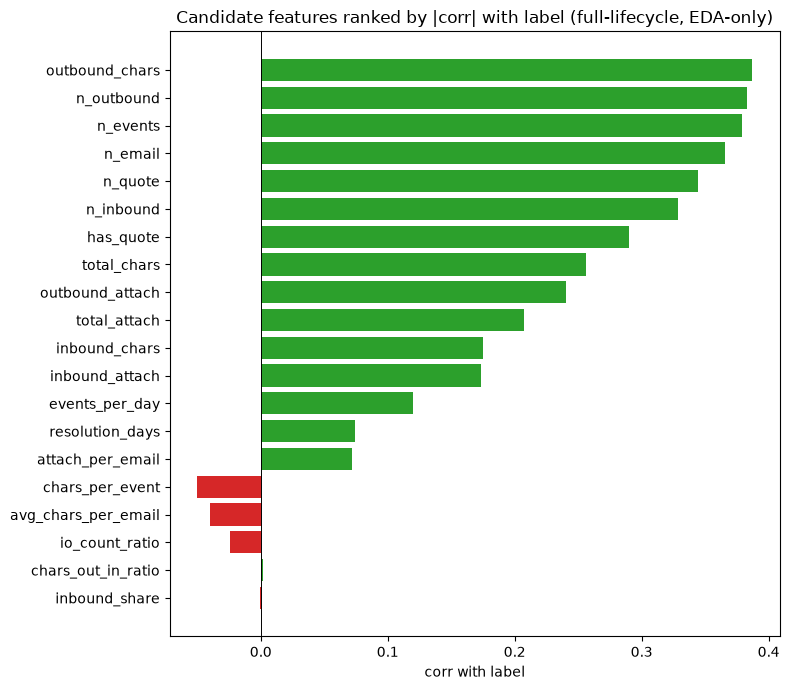

outbound_chars         0.387
n_outbound             0.383
n_events               0.379
n_email                0.366
n_quote                0.344
n_inbound              0.328
has_quote              0.290
total_chars            0.256
outbound_attach        0.240
total_attach           0.208
inbound_chars          0.175
inbound_attach         0.174
events_per_day         0.120
resolution_days        0.075
attach_per_email       0.072
chars_per_event       -0.050
avg_chars_per_email   -0.040
io_count_ratio        -0.024
chars_out_in_ratio     0.002
inbound_share         -0.000


In [6]:
lb = pd.Series({c: feat[c].corr(feat.label) for c in ALL_FEATURES}).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
order = lb.index[::-1]
colors = ["tab:green" if lb[c] >= 0 else "tab:red" for c in order]
ax.barh(order, lb[order].values, color=colors)
ax.axvline(0, color="k", lw=0.7)
ax.set_xlabel("corr with label")
ax.set_title("Candidate features ranked by |corr| with label (full-lifecycle, EDA-only)")
plt.tight_layout(); plt.show()

print(lb.round(3).to_string())

## Mean by label

In [7]:
feat.groupby("label")[lb.index.tolist()].mean().round(2).T

label,0,1
outbound_chars,3761.98,8465.18
n_outbound,9.26,21.22
n_events,16.32,38.12
n_email,15.23,35.62
n_quote,1.09,2.49
n_inbound,5.97,14.41
has_quote,0.57,0.96
total_chars,7957.53,18417.39
outbound_attach,6.12,28.74
total_attach,13.54,54.71


## Distributions by label (top features)

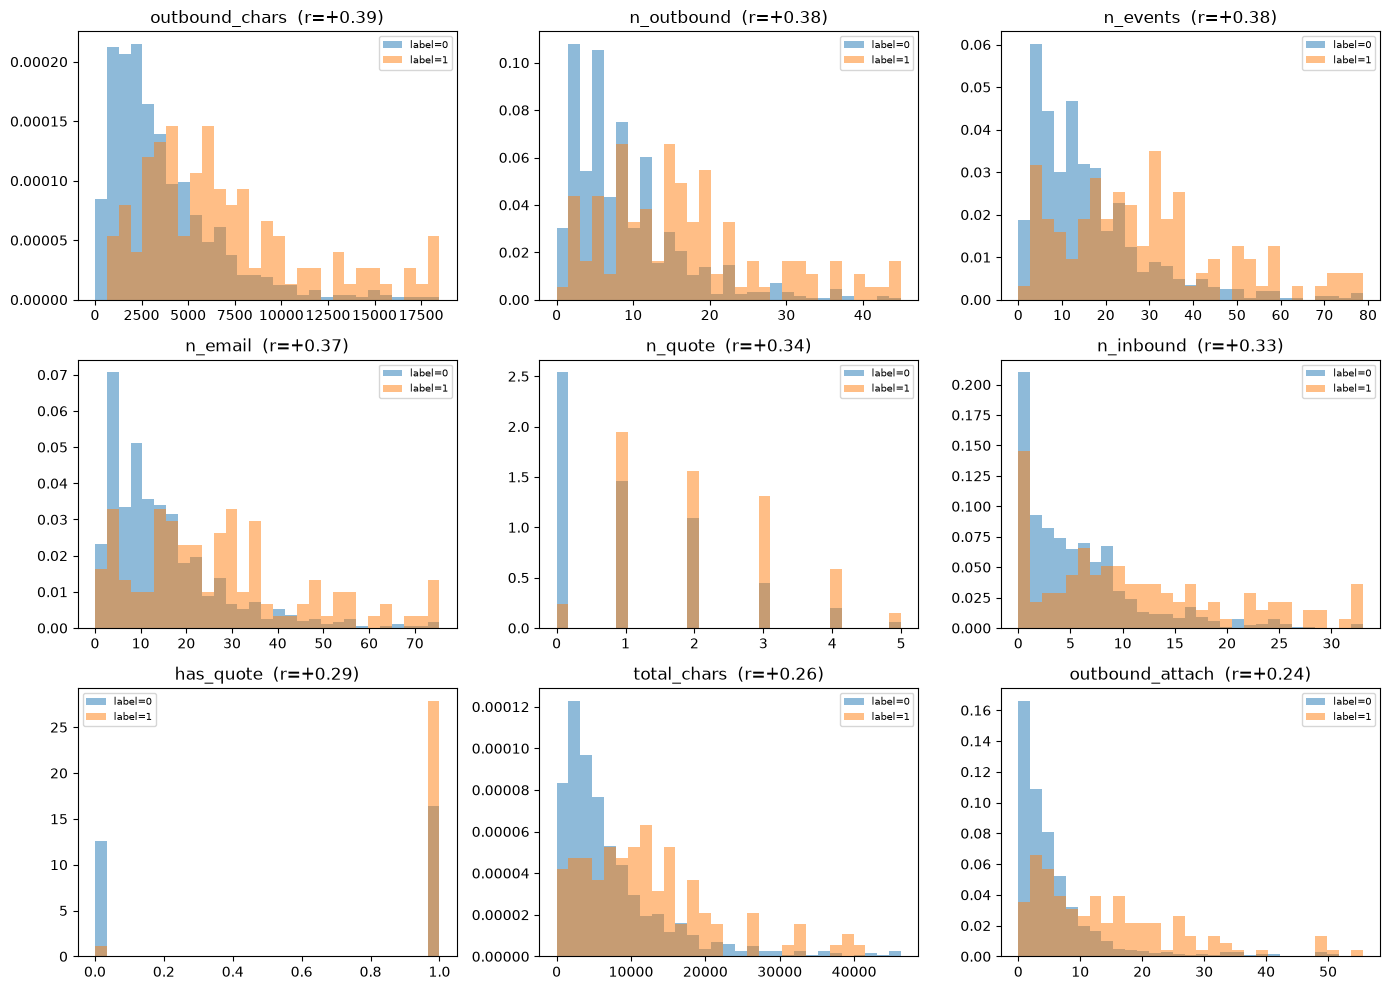

In [8]:
top = lb.index[:9]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), top):
    x = feat[[c, "label"]].dropna()
    lo, hi = x[c].min(), x[c].quantile(0.98)
    bins = np.linspace(lo, hi if hi > lo else x[c].max() + 1, 30)
    for lab, grp in x.groupby("label"):
        ax.hist(grp[c], bins=bins, alpha=0.5, density=True, label=f"label={lab}")
    ax.set_title(f"{c}  (r={lb[c]:+.2f})"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Feature collinearity (redundancy check)
The count/volume features are highly correlated with each other — keep in mind for
feature selection (Task 2) and linear-vs-tree model choice (Phase 2).

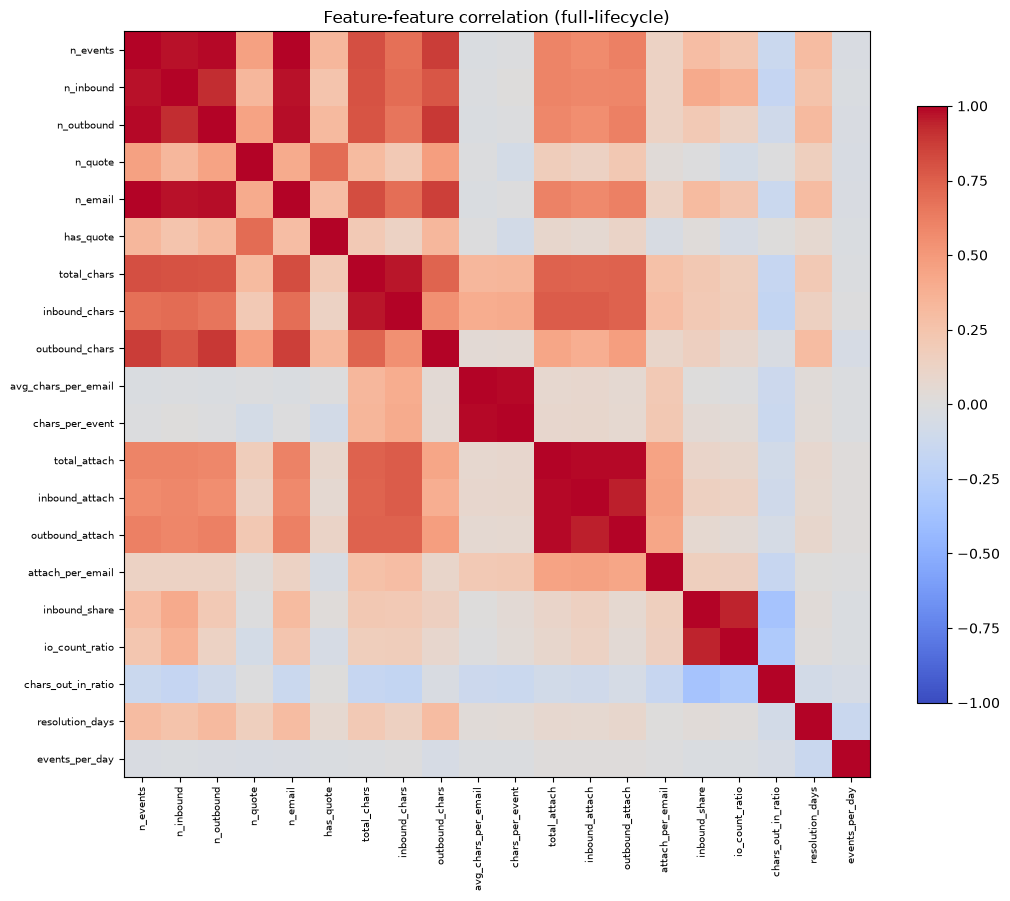

In [9]:
corr = feat[ALL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_FEATURES))); ax.set_xticklabels(ALL_FEATURES, rotation=90, fontsize=7)
ax.set_yticks(range(len(ALL_FEATURES))); ax.set_yticklabels(ALL_FEATURES, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature-feature correlation (full-lifecycle)")
plt.tight_layout(); plt.show()

## Attachments — verdict

**Drop attachments as a standalone feature.** Evidence below:
- attachments split fairly evenly inbound vs outbound (so they don't cleanly proxy "agent supplied docs");
- docs in the *first inbound email* (submission-package completeness) corr ≈ **+0.02** — sold & not-sold both start with ~2.4 attachments;
- per-email attachment rate corr ≈ **+0.07**;
- the only non-trivial attachment correlations (`total_attach`, `outbound_attach`) just ride **email volume** — redundant with `n_outbound`/`n_events`.

Same pattern as the ratios: once volume is normalized away, attachment signal disappears.

In [10]:
em = events[events.event_type.isin(["EMAIL_INBOUND", "EMAIL_OUTBOUND"])]
print("attachments by direction (sum, mean per email):")
print(em.groupby("event_type").email_attachment_count.agg(["sum", "mean"]).round(2), "\n")

inb = events[events.event_type == "EMAIL_INBOUND"].sort_values("event_date")
first_inb = inb.groupby("submissionId").first()
att = subs.set_index("submissionId").copy()
att["first_inbound_attach"] = first_inb.email_attachment_count
att["any_attach"] = events.groupby("submissionId").email_attachment_count.apply(lambda x: (x > 0).any()).astype(float)
for c in ["first_inbound_attach", "any_attach"]:
    print(f"corr(label, {c}) = {att[c].corr(att.label):+.3f}")

attachments by direction (sum, mean per email):
                   sum  mean
event_type                  
EMAIL_INBOUND   8950.0  1.41
EMAIL_OUTBOUND  8333.0  0.86 

corr(label, first_inbound_attach) = +0.024
corr(label, any_attach) = +0.104


## Conclusions — what the EDA told us
- **Imbalanced** (14.8% sold) → this is a *ranking* problem; judge with ROC-AUC / PR-AUC / precision@k, not accuracy.
- **The signal is activity VOLUME + quote PRESENCE.** `outbound_chars` (broker effort) and `has_quote` lead; the volume features are mutually **collinear** (the red block in the heatmap).
- **Most "clever" features are noise** — ratios, attachments, char-distribution stats add nothing once volume is accounted for (confirmed later with partial-correlation + CV-AUC).
- **`t=0` is signal-starved** from activity alone (nothing has happened yet) — a real tension with "early prediction is more valuable."
- **Data cleaned**: 530 duplicate events + 127 impossible pre-creation events removed (see the data-quality cell).

➡️ **The biggest win came _after_ this EDA**: using **repeat-customer history** (`agent_bind_rate`) — the strongest feature, and it rescues the `t=0` blind spot. The full modeling story, feature ranking, and the ranking-capability comparison are in **`02_model.ipynb`**.

## Scratch — play here

In [11]:
# your turn
